<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        PCA: Análisis de Componentes Principales 🧭
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 05
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/05%20-%20Reduccion%20de%20Dimensionalidad/00_PCA.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno abre el **Módulo 05** y desarrolla la primera técnica de la **Sección 2.6 (*Dimensionality reduction*)** del Capítulo 2: el **Análisis de Componentes Principales (PCA)**. PCA es la herramienta de reducción de dimensionalidad más usada del aprendizaje automático y, a la vez, una de las que más se aplica «a ciegas»: se llama a `PCA(n_components=2)` sin saber qué optimiza, qué supone ni cuándo engaña. Aquí **lo derivamos, lo programamos desde cero y lo verificamos contra `scikit-learn`** con `assert`.

Al terminar podrás:

1. **Formular** PCA de dos maneras **equivalentes** (varianza máxima y error de reconstrucción mínimo) y **demostrar** que ambas conducen a los autovectores de la matriz de covarianza.
2. **Justificar** por qué el **centrado** es obligatorio y por qué el **escalado** cambia el resultado.
3. **Conectar** autodescomposición de la covarianza y **SVD** de la matriz centrada, y saber cuál es más estable numéricamente.
4. **Implementar** PCA **desde cero** por ambos caminos y **verificar** que coincide con `sklearn.decomposition.PCA` (componentes salvo signo, varianza explicada, transformada y reconstrucción).
5. **Elegir el número de componentes** con umbral de varianza, codo, criterio de Kaiser, estimación de Minka y verosimilitud validada de forma cruzada.
6. **Interpretar** cargas (*loadings*) y *biplots*, **usar PCA dentro de un `Pipeline`**, **comprimir y reconstruir imágenes** y **blanquear** (*whitening*) los datos.
7. **Reconocer los límites** de PCA (estructura solo lineal, sensibilidad a la escala, varianza $\neq$ relevancia) y conocer **Kernel PCA** e **Incremental PCA**.

> 📍 **Dónde estamos:** Módulo 05, cuaderno 1 de 3. Venimos de la [Introducción al Capítulo 2](../04%20-%20Clustering%20No%20Supervisado/00_Introduccion_Cap2_y_No_Supervisado.ipynb), donde se presentó la **maldición de la dimensionalidad** y se anunció este módulo como una de sus salidas prácticas: **no la repetimos aquí**. Siguen [t-SNE](01_tSNE.ipynb) e [Isomap y variedades](02_Isomap_y_Variedades.ipynb), las dos técnicas **no lineales** que cubren lo que PCA no puede.

> 🔗 **Para no repetir:** el uso práctico de `PCA` con `scikit-learn` (ajuste, *scree plot*, *loadings*, *biplot* y su papel en ingeniería de características) ya se vio en [Data Mining — Módulo 01 (cuaderno 04)](../../Data%20Mining/01%20-%20Preprocesamiento%20de%20los%20Datos/04_Reduccion_de_Dimensionalidad_con_PCA.ipynb) y en [Data Science Programming — Módulo 06 (cuaderno 04)](../../Data%20Science%20programming/06%20-%20Feature%20Engineering/04_PCA_Feature_Engineering.ipynb). Aquí profundizamos en **formulación, implementación propia verificada, criterios de selección y trampas de interpretación**.

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 7 (*Dimensionality Reduction*): *PCA* (*Preserving the Variance*, *Principal Components*, *Explained Variance Ratio*, *Choosing the Right Number of Dimensions*, *PCA for Compression*, *Randomized PCA*, *Incremental PCA*) y *Random Projection* (disponible en `Machine Learning/Libros/`).
- *Python Machine Learning* — **Sebastian Raschka** (Packt, 2015). Cap. 5 (*Compressing Data via Dimensionality Reduction*): *Unsupervised dimensionality reduction via principal component analysis* (*Total and explained variance*, *Feature transformation*, *Principal component analysis in scikit-learn*) y *Using kernel principal component analysis for nonlinear mappings* (disponible en `Machine Learning/Libros/`).
- *Machine Learning Theory and Applications* — **Xavier Vasques** (Wiley, 2024). Cap. 2, §2.5.1.1 (*Principal Component Analysis*) (disponible en `Machine Learning/Libros/`).
- *Machine Learning Methods in the Environmental Sciences* — **William W. Hsieh** (Cambridge University Press, 2009). Cap. 2, §2.1 (*Principal component analysis*) y Cap. 10, §10.4 (*Kernel principal component analysis*) (disponible en `Machine Learning/Libros/`).
- *The Elements of Statistical Learning* — **Hastie, Tibshirani & Friedman**. Cap. 14 (§14.5, *Principal Components, Curves and Surfaces*). *(Capítulo citado de memoria: verifica en tu edición.)*
- Jolliffe, I. T. (2002), *Principal Component Analysis*, 2.ª ed., Springer *(citado de memoria, verificar)*. Pearson (1901) y Hotelling (1933) son los orígenes históricos de la técnica *(citados de memoria, verificar)*.
- Eckart, C. & Young, G. (1936), *The approximation of one matrix by another of lower rank*, **Psychometrika** 1(3): 211–218 *(citado de memoria, verificar)*.
- Minka, T. P. (2000), *Automatic choice of dimensionality for PCA*, **NIPS 2000** *(citado de memoria, verificar)*; Tipping, M. E. & Bishop, C. M. (1999), *Probabilistic principal component analysis*, **JRSS-B** 61(3): 611–622 *(citado de memoria, verificar)*.
- Halko, N., Martinsson, P.-G. & Tropp, J. A. (2011), *Finding structure with randomness*, **SIAM Review** 53(2): 217–288 *(citado de memoria, verificar)*; Schölkopf, B., Smola, A. & Müller, K.-R. (1998), *Nonlinear component analysis as a kernel eigenvalue problem*, **Neural Computation** 10(5): 1299–1319 *(citado de memoria, verificar)*.

### 🌐 Documentación y Recursos Online:
- [scikit-learn: Decomposing signals in components (PCA, Kernel PCA, Incremental PCA)](https://scikit-learn.org/stable/modules/decomposition.html) · [`PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) · [`KernelPCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html) · [`IncrementalPCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.IncrementalPCA.html)
- [scikit-learn: Model selection with Probabilistic PCA and Factor Analysis](https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_vs_fa_model_selection.html)

---
## 1. Dos Formulaciones Equivalentes: Varianza Máxima y Error Mínimo 🎯

### 1.1 Notación y preparación de los datos

Sea $X\in\mathbb{R}^{n\times d}$ la matriz de datos (una fila por observación). PCA **comienza siempre centrando**: restamos la media de cada columna,

$$X_c = X-\mathbf{1}\boldsymbol\mu^\top,\qquad \boldsymbol\mu=\tfrac1n X^\top\mathbf 1,\qquad S=\frac{1}{n-1}X_c^\top X_c\in\mathbb{R}^{d\times d}.$$

$S$ es la **matriz de covarianza muestral**: simétrica y semidefinida positiva, de modo que sus autovalores son reales y no negativos, $\lambda_1\ge\lambda_2\ge\dots\ge\lambda_d\ge0$, con autovectores ortonormales $\mathbf v_1,\dots,\mathbf v_d$. Además $\operatorname{tr}(S)=\sum_j\lambda_j$ es la **varianza total** de los datos.

> ⚠️ **¿Por qué centrar?** Sin centrar, la dirección que maximiza $\mathbf w^\top X^\top X\mathbf w$ apunta **hacia la media** de los datos (el primer «componente» solo describiría dónde están, no cómo varían). El centrado desplaza el origen al centroide para que lo que se maximice sea **dispersión**.

### 1.2 Formulación A: máxima varianza

Proyectamos sobre una dirección unitaria $\mathbf w$ ($\|\mathbf w\|=1$): los datos proyectados son $z_i=\mathbf w^\top\mathbf x_{c,i}$, con varianza $\operatorname{Var}(z)=\mathbf w^\top S\,\mathbf w$. El **primer componente principal** resuelve

$$\max_{\|\mathbf w\|=1}\ \mathbf w^\top S\,\mathbf w .$$

Con el lagrangiano $\mathcal L=\mathbf w^\top S\mathbf w-\lambda(\mathbf w^\top\mathbf w-1)$ y $\nabla_{\mathbf w}\mathcal L=2S\mathbf w-2\lambda\mathbf w=\mathbf 0$ se obtiene

$$S\,\mathbf w=\lambda\,\mathbf w\quad\Longrightarrow\quad \mathbf w^\top S\mathbf w=\lambda,$$

es decir, **$\mathbf w$ es un autovector de $S$ y la varianza que captura es su autovalor**; el máximo se alcanza con el **mayor** autovalor, $\mathbf w_1=\mathbf v_1$. El segundo componente maximiza la misma cantidad **restringido a ser ortogonal** al primero, y así sucesivamente (teorema de Courant–Fischer: el cociente de Rayleigh $\mathbf w^\top S\mathbf w/\mathbf w^\top\mathbf w$ tiene como valores estacionarios los autovalores).

### 1.3 Formulación B: error de reconstrucción mínimo

Ahora buscamos un subespacio de dimensión $m$, con base ortonormal $W_m\in\mathbb{R}^{d\times m}$ ($W_m^\top W_m=I_m$), tal que **proyectar y volver** pierda lo menos posible: $\hat{\mathbf x}_i=W_mW_m^\top\mathbf x_{c,i}$. Como $\mathbf x-W_mW_m^\top\mathbf x\perp W_mW_m^\top\mathbf x$, el **teorema de Pitágoras** da $\|\mathbf x-\hat{\mathbf x}\|^2=\|\mathbf x\|^2-\|W_m^\top\mathbf x\|^2$ y, sumando sobre todos los datos,

$$E(W_m)=\sum_{i=1}^n\|\mathbf x_{c,i}-W_mW_m^\top\mathbf x_{c,i}\|^2=\underbrace{(n-1)\operatorname{tr}(S)}_{\text{constante}}-(n-1)\,\operatorname{tr}\!\big(W_m^\top S\,W_m\big).$$

Minimizar el error equivale a **maximizar la varianza retenida** $\operatorname{tr}(W_m^\top SW_m)$: **las dos formulaciones son la misma**. El máximo se alcanza con los $m$ autovectores de mayor autovalor, y el error mínimo vale

$$E_{\min}=(n-1)\sum_{j=m+1}^{d}\lambda_j\qquad(\text{la varianza de los componentes descartados}).$$

Este resultado es un caso del **teorema de Eckart–Young–Mirsky**: la mejor aproximación de rango $m$ de $X_c$ en norma de Frobenius es la SVD truncada (*citado de memoria, verificar*).

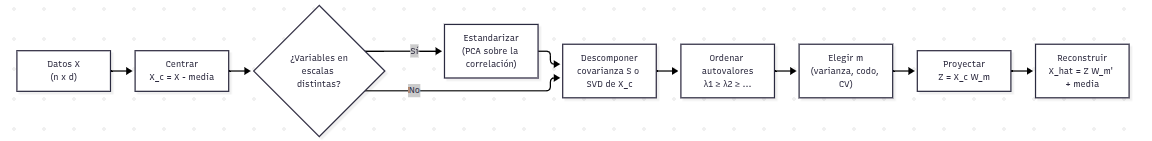

Lo comprobamos numéricamente en 2 dimensiones: barremos **todas las direcciones** $\mathbf w(\theta)=(\cos\theta,\sin\theta)$ y calculamos, para cada una, la varianza proyectada y el error de reconstrucción. Deben cumplir $\text{varianza}+\text{error}=\operatorname{tr}(S)$ (constante) y, por tanto, **el ángulo que maximiza una minimiza el otro**, que además coincide con el del primer autovector.

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn scipy

import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits, load_wine, make_circles
from sklearn.decomposition import PCA, KernelPCA, IncrementalPCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, KFold

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
PALETA = ["#2563eb", "#dc2626", "#16a34a", "#f59e0b", "#7c3aed", "#0891b2", "#db2777", "#65a30d"]
print("Entorno listo.")

# ============================================================
# 1. Varianza maxima  <=>  error de reconstruccion minimo (barrido de direcciones en 2D)
# ============================================================
rng = np.random.RandomState(SEED)
n = 300
A = np.array([[2.0, 0.0], [1.2, 0.8]])                      # mezcla lineal: genera correlacion entre x1 y x2
X2 = rng.randn(n, 2) @ A.T + np.array([3.0, -1.0])          # nube elongada, lejos del origen
Xc = X2 - X2.mean(axis=0)                                   # CENTRADO
S = Xc.T @ Xc / (n - 1)                                     # covarianza muestral

theta = np.linspace(0, np.pi, 361)                          # direcciones w = (cos t, sin t), paso de 0.5 grados
W = np.c_[np.cos(theta), np.sin(theta)]
var_proy = np.einsum("ij,jk,ik->i", W, S, W)                # w' S w para cada direccion
err_rec = np.array([((Xc - np.outer(Xc @ w, w)) ** 2).sum() / (n - 1) for w in W])   # error medio de reconstruccion
total = np.trace(S)

lam, V = np.linalg.eigh(S)
lam, V = lam[::-1], V[:, ::-1]                              # orden decreciente
ang_pc1 = np.arctan2(V[1, 0], V[0, 0]) % np.pi

assert np.allclose(var_proy + err_rec, total)               # Pitagoras: varianza + error = varianza total (constante)
assert theta[var_proy.argmax()] == theta[err_rec.argmin()]  # el mismo angulo maximiza una y minimiza el otro
assert abs(theta[var_proy.argmax()] - ang_pc1) <= np.pi / 360 + 1e-12   # ... y coincide con el primer autovector (paso de la malla)
assert np.isclose(var_proy.max(), lam[0], rtol=1e-3)        # la varianza maxima es el mayor autovalor
print(f"Varianza total tr(S) = {total:.3f} = lambda1 + lambda2 = {lam[0]:.3f} + {lam[1]:.3f}")
print(f"Mejor angulo en la malla: {np.degrees(theta[var_proy.argmax()]):.1f} grados; angulo del autovector v1: {np.degrees(ang_pc1):.1f} grados")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
ax.scatter(*Xc.T, s=14, alpha=0.45, color=PALETA[0])
for j, (c, nombre) in enumerate(zip([PALETA[1], PALETA[2]], ["PC1", "PC2"])):
    ax.annotate("", xy=2 * np.sqrt(lam[j]) * V[:, j], xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=c, lw=3))
    ax.text(*(2.25 * np.sqrt(lam[j]) * V[:, j]), nombre, color=c, fontweight="bold")
w_mal = np.array([np.cos(np.radians(110)), np.sin(np.radians(110))])      # una direccion cualquiera, mala
proj = np.outer(Xc @ w_mal, w_mal)
for i in range(0, n, 12):
    ax.plot([Xc[i, 0], proj[i, 0]], [Xc[i, 1], proj[i, 1]], color="gray", lw=0.7, alpha=0.7)
ax.plot(*np.c_[-6 * w_mal, 6 * w_mal], "--", color="gray", lw=1.5, label="una dirección mala (110°): errores largos")
ax.set_aspect("equal"); ax.set_xlabel("$x_1$ (centrado)"); ax.set_ylabel("$x_2$ (centrado)"); ax.legend(fontsize=8, loc="lower left")
ax.set_title("Datos centrados, componentes principales y un mal eje de proyección", fontweight="bold", fontsize=10)

ax = axes[1]
ax.plot(np.degrees(theta), var_proy, color=PALETA[0], lw=2.5, label=r"Varianza proyectada $\mathbf{w}^\top S\mathbf{w}$")
ax.plot(np.degrees(theta), err_rec, color=PALETA[1], lw=2.5, label="Error medio de reconstrucción")
ax.axhline(total, color="black", ls=":", label=r"Suma = $\mathrm{tr}(S)$ (constante)")
ax.axvline(np.degrees(ang_pc1), color=PALETA[2], ls="--", label="ángulo del autovector $\\mathbf{v}_1$")
ax.set_xlabel("Ángulo $\\theta$ de la dirección de proyección (grados)"); ax.set_ylabel("Valor")
ax.set_title("Maximizar la varianza = minimizar el error de reconstrucción", fontweight="bold", fontsize=10); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 2. Derivación con la Covarianza y con la SVD; Implementación desde Cero 🛠️

### 2.1 Dos caminos hacia los mismos componentes

**(a) Autodescomposición de la covarianza.** Se forma $S$ y se calcula $S=V\Lambda V^\top$. Las columnas de $V$ son los **componentes** (direcciones) y $\Lambda=\operatorname{diag}(\lambda_j)$ las **varianzas explicadas**.

**(b) SVD de la matriz centrada.** Si $X_c=U\Sigma V^\top$ (SVD «económica»), entonces

$$X_c^\top X_c=V\Sigma^\top U^\top U\Sigma V^\top=V\Sigma^2V^\top\ \Longrightarrow\ S=V\,\frac{\Sigma^2}{n-1}\,V^\top,\qquad \boxed{\lambda_j=\frac{\sigma_j^2}{n-1}}$$

y los **puntajes** (*scores*, coordenadas en el nuevo sistema) son $Z=X_cV=U\Sigma$. Las columnas de $Z$ están **incorreladas** y $\operatorname{Var}(Z_{\cdot j})=\lambda_j$. Tras centrar, el rango es a lo sumo $\min(n-1,d)$.

**¿Cuál usar?** Matemáticamente son idénticos, pero **numéricamente la SVD es mejor**: al formar $X_c^\top X_c$ se **eleva al cuadrado el número de condición**, y los componentes de varianza muy pequeña se pierden en el error de redondeo. Por eso `scikit-learn` usa SVD (*LAPACK*) en `svd_solver="full"`, ARPACK en `"arpack"` y la SVD aleatorizada de Halko et al. (2011) en `"randomized"` (y, desde la versión 1.5, la autodescomposición de la covarianza como `"covariance_eigh"` cuando $n\gg d$).

### 2.2 La ambigüedad de signo

Si $\mathbf v$ es un autovector, **$-\mathbf v$ también lo es**: el signo de cada componente **no está determinado** por la matemática, solo por una convención del *software*. `scikit-learn` fija el signo con `svd_flip` (la convención ha cambiado entre versiones), y nosotros elegiremos la misma idea: que el **coeficiente de mayor valor absoluto de cada componente sea positivo**. Por eso **compararemos «salvo signo»**: alinearemos el signo de cada componente antes de usar `np.allclose`. Si hubiera autovalores **repetidos**, el subespacio sería único pero **no sus direcciones**; no es el caso en nuestros datos.

Implementamos una clase con ambos *solvers* y la verificamos contra `PCA(svd_solver="full")` en **tres escenarios**: *Wine* estandarizado ($n=178,\ d=13$), *Dígitos* ($n=1797,\ d=64$, con píxeles constantes) y un caso **ancho** ($n=40<d=200$).

In [ ]:
# ============================================================
# 2. PCA DESDE CERO (autodescomposicion de la covarianza y SVD), verificado contra sklearn.decomposition.PCA
# ============================================================
class PCAdesdeCero:
    """PCA con dos solvers: 'eigen' (eigh de la covarianza) y 'svd' (SVD de la matriz centrada)."""
    def __init__(self, n_components=None, solver="svd", whiten=False):
        self.n_components, self.solver, self.whiten = n_components, solver, whiten

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        n, d = X.shape
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_                                          # 1) centrar
        if self.solver == "eigen":
            S = Xc.T @ Xc / (n - 1)                                  # 2a) covarianza muestral
            lam, V = np.linalg.eigh(S)                               # eigh: simetrica -> autovalores crecientes
            orden = np.argsort(lam)[::-1]
            lam, comps = np.clip(lam[orden], 0, None), V[:, orden].T  # decreciente; cada FILA es un componente
        else:
            _, s, comps = np.linalg.svd(Xc, full_matrices=False)     # 2b) SVD economica: Xc = U diag(s) Vt
            lam = s ** 2 / (n - 1)                                   # lambda_j = sigma_j^2 / (n-1)
        # convencion de signo: el coeficiente de mayor |valor| de cada componente es positivo
        signo = np.sign(comps[np.arange(len(comps)), np.abs(comps).argmax(axis=1)])
        comps = comps * np.where(signo == 0, 1.0, signo)[:, None]
        k = self.n_components or len(lam)
        self.components_ = comps[:k]
        self.explained_variance_ = lam[:k]
        self.total_variance_ = Xc.var(axis=0, ddof=1).sum()          # tr(S) = suma de TODOS los autovalores
        self.explained_variance_ratio_ = lam[:k] / self.total_variance_
        return self

    def transform(self, X):
        Z = (np.asarray(X, dtype=float) - self.mean_) @ self.components_.T      # 3) proyectar: Z = Xc W
        if self.whiten:
            Z = Z / np.sqrt(np.where(self.explained_variance_ > 1e-12, self.explained_variance_, 1.0))
        return Z

    def inverse_transform(self, Z):
        if self.whiten:
            Z = Z * np.sqrt(self.explained_variance_)
        return Z @ self.components_ + self.mean_                                # 4) reconstruir: X_hat = Z W' + media

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def alinear_signo(A, B):
    """Multiplica cada FILA de A por +-1 para que apunte en el mismo sentido que la de B (ambiguedad de signo)."""
    return A * np.sign((A * B).sum(axis=1))[:, None]

# --- Tres escenarios de verificacion ---
wine = load_wine().data
wine_z = (wine - wine.mean(0)) / wine.std(0, ddof=1)                         # estandarizado
digitos = load_digits().data
r = np.random.RandomState(SEED)
ancho = r.randn(40, 6) @ r.randn(6, 200) + 0.1 * r.randn(40, 200)            # n=40 < d=200, casi de rango 6
escenarios = {"Wine estandarizado (13 vars)": (wine_z, 13), "Dígitos (64 vars, primeros 20 comp.)": (digitos, 20), "Ancho n=40 < d=200 (primeros 10)": (ancho, 10)}

filas = []
for nombre, (X, k) in escenarios.items():
    sk = PCA(n_components=k, svd_solver="full").fit(X)
    Zsk = sk.transform(X)
    for solver in ["eigen", "svd"]:
        mi = PCAdesdeCero(n_components=k, solver=solver).fit(X)
        Cm = alinear_signo(mi.components_, sk.components_)
        dif_comp = np.abs(Cm - sk.components_).max()
        assert np.allclose(Cm, sk.components_, atol=1e-6), (nombre, solver)                    # componentes (salvo signo)
        assert np.allclose(mi.explained_variance_, sk.explained_variance_, rtol=1e-8, atol=1e-10)         # varianza explicada
        assert np.allclose(mi.explained_variance_ratio_, sk.explained_variance_ratio_, atol=1e-10)         # razon de varianza
        Zm = mi.transform(X) * np.sign((Cm * mi.components_).sum(axis=1))             # llevar los puntajes al signo de sklearn
        assert np.allclose(Zm, Zsk, atol=1e-6)                                         # transformada
        Xrec = mi.inverse_transform(mi.transform(X))
        assert np.allclose(Xrec, sk.inverse_transform(Zsk), atol=1e-6)                 # reconstruccion
        filas.append({"escenario": nombre, "solver": solver, "max |componente - sklearn|": dif_comp,
                      "¿signos ya coinciden?": bool(np.all(np.sign((mi.components_ * sk.components_).sum(1)) > 0))})
print("PCA propio == sklearn.decomposition.PCA (componentes salvo signo, varianza explicada, transformada y reconstrucción)")
print("en los 3 escenarios y con los 2 solvers.\n")
display(pd.DataFrame(filas))

# --- Propiedades teoricas sobre Wine estandarizado ---
mi = PCAdesdeCero(solver="svd").fit(wine_z)
Z = mi.transform(wine_z)
assert np.allclose(mi.components_ @ mi.components_.T, np.eye(13), atol=1e-10)                       # componentes ortonormales
assert np.allclose(np.cov(Z, rowvar=False), np.diag(mi.explained_variance_), atol=1e-8)            # puntajes incorrelados, Var = lambda
m = 3
Xrec = PCAdesdeCero(n_components=m).fit(wine_z).inverse_transform(PCAdesdeCero(n_components=m).fit(wine_z).transform(wine_z))
err = ((wine_z - Xrec) ** 2).sum()
assert np.isclose(err, (len(wine_z) - 1) * mi.explained_variance_[m:].sum())                        # E_min = (n-1) * suma de lambda descartados
print(f"\nComponentes ortonormales, puntajes incorrelados con Var(Z_j) = lambda_j, y error de reconstrucción con m={m}: "
      f"{err:.2f} = (n-1) * suma de los lambda descartados.")

In [ ]:
# ============================================================
# 2b. Estabilidad numerica: autovalores de la covarianza vs SVD con valores singulares muy dispares
# Datos con valores singulares CONOCIDOS que bajan de 1 a 1e-9 (varianzas verdaderas sigma^2/(n-1), de ~5e-3 a ~1e-21):
# la covarianza eleva al cuadrado el numero de condicion y pierde los ultimos componentes; la SVD no.
# ============================================================
r = np.random.RandomState(SEED)
n, d = 200, 10
G = r.randn(n, d); G -= G.mean(axis=0)                          # columnas de media cero  =>  U0 (de la QR) tambien tiene media cero
U0, _ = np.linalg.qr(G); V0, _ = np.linalg.qr(r.randn(d, d))
sv = np.logspace(0, -9, d)                                      # valores singulares verdaderos: 1, ..., 1e-9
Xs = (U0 * sv) @ V0.T                                           # Xs = U diag(sv) V'  (ya centrada)
verd = np.linalg.svd(Xs, compute_uv=False, full_matrices=False) ** 2 / (n - 1)    # referencia: SVD
lam_cov = np.sort(np.linalg.eigvalsh(Xs.T @ Xs / (n - 1)))[::-1]                    # autovalores de la covarianza
tabla = pd.DataFrame({"varianza teórica σ²/(n-1)": sv ** 2 / (n - 1), "vía SVD de X_c": verd, "vía eigh(covarianza)": lam_cov})
tabla["error relativo eigh vs SVD"] = np.abs(lam_cov - verd) / verd
with pd.option_context("display.float_format", "{:.3e}".format):
    display(tabla)
print("Los autovalores de la covarianza pierden por completo los últimos componentes (error relativo ~ 1 o mayor), "
      "porque su precisión absoluta es ~ 1e-16 * lambda_max; la SVD los conserva con precisión relativa.")
assert tabla["error relativo eigh vs SVD"].iloc[-1] > 1.0 and tabla["error relativo eigh vs SVD"].iloc[0] < 1e-8

---
##### 🛠️ Práctica 1: La SVD y la covarianza cuentan la misma historia

En la Sección 2.1 vimos que, si $X_c=U\Sigma V^\top$, entonces $\lambda_j=\sigma_j^2/(n-1)$ y los puntajes son $Z=X_cV=U\Sigma$. Compruébalo con *Wine* estandarizado (`wine_z`) y la clase `PCAdesdeCero`:

1. Centra `wine_z` (`Xc_w`) y calcula su SVD económica: `U_w, s_w, Vt_w = np.linalg.svd(Xc_w, full_matrices=False)`.
2. Obtén `lam_w = s_w**2 / (n_w - 1)` (con `n_w = len(wine_z)`) y verifica con `assert` que coincide con `explained_variance_` de `PCAdesdeCero(solver="eigen").fit(wine_z)`.
3. Verifica con `assert` que los puntajes `U_w * s_w` coinciden con los de `PCAdesdeCero(solver="svd").fit_transform(wine_z)` **salvo el signo de cada columna** (usa `alinear_signo` sobre las transpuestas).
4. Como `wine_z` está estandarizado, la varianza total es el número de variables: verifica con `assert` que `lam_w.sum()` vale $13$ e imprime el porcentaje de varianza de los dos primeros componentes.

In [ ]:
# Escribe tu código aquí

# Xc_w = wine_z - wine_z.mean(axis=0)
# U_w, s_w, Vt_w = np.linalg.svd(...)
# n_w = len(wine_z)
# lam_w = ...
# assert np.allclose(lam_w, PCAdesdeCero(solver="eigen").fit(wine_z).explained_variance_)
# Z_mio = PCAdesdeCero(solver="svd").fit_transform(wine_z)
# Z_svd = alinear_signo((U_w * s_w).T, Z_mio.T).T      # (alinear_signo trabaja por filas: por eso las transpuestas)
# assert ...
# assert ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Centrar y SVD economica: Xc = U diag(s) Vt
Xc_w = wine_z - wine_z.mean(axis=0)
U_w, s_w, Vt_w = np.linalg.svd(Xc_w, full_matrices=False)

# 2) lambda_j = sigma_j^2 / (n-1) debe coincidir con la autodescomposicion de la covarianza
n_w = len(wine_z)
lam_w = s_w ** 2 / (n_w - 1)
assert np.allclose(lam_w, PCAdesdeCero(solver="eigen").fit(wine_z).explained_variance_)

# 3) Puntajes Z = U Sigma = Xc V, salvo el signo de cada componente
Z_mio = PCAdesdeCero(solver="svd").fit_transform(wine_z)
Z_svd = alinear_signo((U_w * s_w).T, Z_mio.T).T      # alinear_signo cambia el signo por FILAS -> usamos las transpuestas
assert np.allclose(Z_svd, Z_mio, atol=1e-8)

# 4) Varianza total = traza de la matriz de correlacion = numero de variables (13)
assert np.isclose(lam_w.sum(), 13.0)
print(f"Varianza total = {lam_w.sum():.2f} (13 variables estandarizadas)")
print(f"PC1 + PC2 explican {100 * lam_w[:2].sum() / lam_w.sum():.1f} % de la varianza")
```
</details>

---


---
## 3. ¿Cuántos Componentes Conservar? 🎚️

La **razón de varianza explicada** del componente $j$ es $\rho_j=\lambda_j/\sum_k\lambda_k$ y la **acumulada** $\sum_{j\le m}\rho_j$ mide qué fracción de la varianza (equivalentemente, $1-E_{\min}/E_{\text{total}}$) retiene un subespacio de dimensión $m$. No existe una regla universal; los criterios más usados son:

| Criterio | Regla | Comentario |
|---|---|---|
| **Umbral de varianza** | el menor $m$ con $\sum_{j\le m}\rho_j\ge 0.90,\ 0.95,\ 0.99$ | Simple y transparente; el umbral es arbitrario |
| **Codo** (*scree plot*) | donde la curva de $\lambda_j$ deja de caer abruptamente | Subjetivo; se puede automatizar con la distancia a la cuerda |
| **Kaiser** | $\lambda_j>\bar\lambda$ (con datos estandarizados: $\lambda_j>1$) | Solo conserva componentes mejores que «una variable media»; suele retener demasiados o muy pocos |
| **Minka (MLE)** | máxima verosimilitud bayesiana de la dimensión bajo PCA probabilístico (`n_components="mle"`) | Supone un modelo gaussiano de ruido isótropo |
| **Verosimilitud validada** | $m$ que maximiza el *log-likelihood* promedio **en datos retenidos** del modelo PPCA | Criterio predictivo, el más defendible |

> ⚠️ **Trampa de la validación cruzada ingenua:** el error de reconstrucción **en datos de validación** también decrece *siempre* con $m$ si el subespacio de $m$ dimensiones contiene al de $m-1$ (proyectar sobre más direcciones nunca aumenta el residuo). Por eso **no tiene un mínimo** que señale el $m$ correcto (solo un codo subjetivo) y se prefiere la **verosimilitud** del modelo probabilístico (Tipping & Bishop, 1999), que **penaliza** el sobreajuste al ruido. Lo mostramos abajo con datos de **rango verdadero 5** más ruido.

In [ ]:
# ============================================================
# 3. Criterios para elegir el numero de componentes (Dígitos)
# ============================================================
Xd, yd = load_digits(return_X_y=True)
pca_full = PCA(svd_solver="full").fit(Xd)
lam_d = pca_full.explained_variance_
rho = pca_full.explained_variance_ratio_
acum = np.cumsum(rho)

def codo_distancia_cuerda(valores):
    """Codo = punto de la curva mas alejado de la recta (cuerda) que une el primer y el ultimo punto, con ambos ejes normalizados a [0, 1]."""
    x = np.linspace(0, 1, len(valores))
    y = (valores - valores.min()) / (valores.max() - valores.min())
    u = np.array([x[-1] - x[0], y[-1] - y[0]]); u = u / np.linalg.norm(u)
    dist = np.abs(u[0] * (y - y[0]) - u[1] * (x - x[0]))        # producto cruz 2D = distancia perpendicular a la cuerda
    return int(dist.argmax()) + 1                                # numero de componentes (indice + 1)

m_umbral = {u: int(np.searchsorted(acum, u) + 1) for u in (0.90, 0.95, 0.99)}
m_kaiser = int((lam_d > lam_d.mean()).sum())
m_codo = codo_distancia_cuerda(lam_d)                             # codo del scree plot (escala lineal normalizada)
m_mle = PCA(n_components="mle", svd_solver="full").fit(Xd).n_components_
m_sk95 = PCA(n_components=0.95, svd_solver="full").fit(Xd).n_components_
assert m_sk95 == m_umbral[0.95]                                  # n_components=0.95 de sklearn == nuestro umbral

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].semilogy(np.arange(1, 65), lam_d, "o-", color=PALETA[0], ms=4)
axes[0].axhline(lam_d.mean(), color=PALETA[3], ls="--", label=f"Kaiser: λ > media → {m_kaiser} comp.")
axes[0].axvline(m_codo, color=PALETA[1], ls="--", label=f"codo (cuerda) → {m_codo} comp.")
axes[0].set_ylim(1e-4, 1e3); axes[0].set_xlabel("Componente $j$"); axes[0].set_ylabel("Autovalor $\\lambda_j$ (escala log)")
axes[0].set_title("Scree plot de los dígitos (64 variables)", fontweight="bold", fontsize=10); axes[0].legend(fontsize=8)
axes[1].plot(np.arange(1, 65), acum, "o-", color=PALETA[2], ms=4)
for u, c in zip((0.90, 0.95, 0.99), (PALETA[3], PALETA[1], PALETA[4])):
    axes[1].axhline(u, color=c, ls=":"); axes[1].axvline(m_umbral[u], color=c, ls=":", label=f"{int(u*100)} % → {m_umbral[u]} comp.")
axes[1].set_xlabel("Número de componentes $m$"); axes[1].set_ylabel("Varianza explicada acumulada")
axes[1].set_title("Varianza explicada acumulada", fontweight="bold", fontsize=10); axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

display(pd.DataFrame({"criterio": ["umbral 90 %", "umbral 95 %", "umbral 99 %", "Kaiser (λ > media)", "codo (cuerda)", "Minka (MLE)"],
                      "componentes": [m_umbral[0.90], m_umbral[0.95], m_umbral[0.99], m_kaiser, m_codo, m_mle]}).set_index("criterio").T)
print("Los criterios NO coinciden: elegir m es una decisión de modelado, no un cálculo exacto. Depende del objetivo (visualizar, comprimir, predecir).")
print("(El MLE de Minka asume ruido gaussiano isótropo; con datos reales de ruido heterogéneo, como los píxeles constantes de los dígitos, suele sobreestimar m.)")

In [ ]:
# ============================================================
# 3b. Validacion cruzada: reconstruccion retenida (siempre baja) vs verosimilitud PPCA (tiene un maximo)
# ============================================================
r = np.random.RandomState(SEED)
n, d, rango = 500, 30, 5
escalas = np.array([5.0, 4.0, 3.0, 2.5, 2.0])                    # 5 factores latentes de intensidad decreciente
Xl = (r.randn(n, rango) * escalas) @ np.linalg.qr(r.randn(d, rango))[0].T + 0.7 * r.randn(n, d)     # rango 5 + ruido

ms = np.arange(1, 16)
kf = KFold(5, shuffle=True, random_state=SEED)
ll_cv = [cross_val_score(PCA(n_components=m, svd_solver="full"), Xl, cv=kf).mean() for m in ms]      # PCA.score = log-verosimilitud PPCA media
rec_train, rec_test = [], []
for m in ms:
    e_tr, e_te = [], []
    for tr, te in kf.split(Xl):
        mod = PCAdesdeCero(n_components=m).fit(Xl[tr])
        e_tr.append(((Xl[tr] - mod.inverse_transform(mod.transform(Xl[tr]))) ** 2).mean())
        e_te.append(((Xl[te] - mod.inverse_transform(mod.transform(Xl[te]))) ** 2).mean())
    rec_train.append(np.mean(e_tr)); rec_test.append(np.mean(e_te))

m_cv = int(ms[int(np.argmax(ll_cv))]); m_mle = PCA(n_components="mle", svd_solver="full").fit(Xl).n_components_
assert np.all(np.diff(rec_test) <= 1e-12)                        # el error de reconstruccion en validacion NUNCA sube con m (subespacios anidados)
assert m_cv == rango and m_mle == rango                          # la verosimilitud validada y Minka recuperan el rango verdadero (5)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].plot(ms, rec_train, "o-", color=PALETA[0], label="entrenamiento")
axes[0].plot(ms, rec_test, "s--", color=PALETA[1], label="validación (datos retenidos)")
axes[0].axvline(rango, color="gray", ls=":", label="rango verdadero = 5")
axes[0].set_xlabel("Número de componentes $m$"); axes[0].set_ylabel("Error cuadrático medio de reconstrucción")
axes[0].set_title("Reconstrucción: siempre baja con $m$ (solo un codo subjetivo)", fontweight="bold", fontsize=10); axes[0].legend(fontsize=8)
axes[1].plot(ms, ll_cv, "o-", color=PALETA[2])
axes[1].axvline(m_cv, color=PALETA[2], ls="--", label=f"máximo en m = {m_cv}"); axes[1].axvline(rango, color="gray", ls=":", label="rango verdadero = 5")
axes[1].set_xlabel("Número de componentes $m$"); axes[1].set_ylabel("Log-verosimilitud PPCA en validación (media)")
axes[1].set_title("Verosimilitud validada: tiene un máximo en el rango verdadero", fontweight="bold", fontsize=10); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"Rango verdadero = {rango} | verosimilitud validada → m = {m_cv} | Minka (MLE) → m = {m_mle}")

---
##### 🛠️ Práctica 2: ¿Cuántos componentes para Wine? Cuatro criterios

En la Sección 3 comparamos criterios con los dígitos. Aplícalos ahora a *Wine* estandarizado (`wine_z`, 13 variables) y comprueba que **tampoco coinciden**:

1. Ajusta `PCA(svd_solver="full")` sobre `wine_z`, toma `lam_ww = explained_variance_` y la razón acumulada `acum_w = np.cumsum(lam_ww) / lam_ww.sum()`.
2. Calcula `m_80` y `m_90` (el menor $m$ cuya varianza acumulada alcanza 80 % y 90 %) con `np.searchsorted`, y verifica con `assert` que coinciden con `PCA(n_components=0.80).fit(wine_z).n_components_` (y análogo para 0.90).
3. Calcula `m_kaiser_w` (cuántos $\lambda_j>1$; con datos estandarizados $1$ es la media de los $\lambda_j$) y `m_codo_w` con la función `codo_distancia_cuerda` de la Sección 3.
4. Muestra los cuatro números en una tabla y verifica con `assert` que `m_kaiser_w < m_90`. Comenta: ¿cuál elegirías para visualizar y cuál para comprimir?

In [ ]:
# Escribe tu código aquí

# lam_ww = PCA(svd_solver="full").fit(wine_z).explained_variance_
# acum_w = np.cumsum(lam_ww) / lam_ww.sum()
# m_80 = int(np.searchsorted(acum_w, 0.80) + 1)
# m_90 = ...
# assert m_80 == PCA(n_components=0.80, svd_solver="full").fit(wine_z).n_components_
# assert ...
# m_kaiser_w = int((lam_ww > 1).sum())
# m_codo_w = codo_distancia_cuerda(lam_ww)
# display(pd.DataFrame(...))


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Espectro de Wine estandarizado y varianza acumulada
lam_ww = PCA(svd_solver="full").fit(wine_z).explained_variance_
acum_w = np.cumsum(lam_ww) / lam_ww.sum()

# 2) Umbrales de varianza (el mismo calculo que n_components=0.80 / 0.90 de sklearn)
m_80 = int(np.searchsorted(acum_w, 0.80) + 1)
m_90 = int(np.searchsorted(acum_w, 0.90) + 1)
assert m_80 == PCA(n_components=0.80, svd_solver="full").fit(wine_z).n_components_
assert m_90 == PCA(n_components=0.90, svd_solver="full").fit(wine_z).n_components_

# 3) Kaiser (lambda > 1: media de los lambda con datos estandarizados) y codo por la cuerda
m_kaiser_w = int((lam_ww > 1).sum())
assert m_kaiser_w == int((lam_ww > lam_ww.mean()).sum())
m_codo_w = codo_distancia_cuerda(lam_ww)

# 4) Los criterios no coinciden: Kaiser es el mas exigente, el umbral del 90 % el mas generoso
assert m_kaiser_w < m_90
display(pd.DataFrame({"criterio": ["umbral 80 %", "umbral 90 %", "Kaiser (λ > 1)", "codo (cuerda)"],
                      "componentes": [m_80, m_90, m_kaiser_w, m_codo_w]}).set_index("criterio").T)
# Para visualizar basta m = 2 o 3; para comprimir sin perder casi nada, el umbral alto (m_90).
```
</details>

---


---
## 4. Interpretar Cargas (*Loadings*) y *Biplots* 🔍

Cada componente es una **combinación lineal** de las variables originales: $\text{PC}_j=\sum_k v_{kj}\,x_k$. Los coeficientes $v_{kj}$ indican **con qué peso y signo** participa cada variable. En la práctica se llaman **cargas** (*loadings*) a la versión escalada

$$L_{kj}=v_{kj}\sqrt{\lambda_j},\qquad L_{kj}=\operatorname{corr}(x_k,\ \text{PC}_j)\ \ \text{si los datos están estandarizados}.$$

Es decir, con datos estandarizados la carga es **la correlación** entre la variable $k$ y el componente $j$ (y $\sum_j L_{kj}^2=1$: cada variable queda explicada al 100 % por *todos* los componentes). Un ***biplot*** dibuja a la vez los **puntajes** (observaciones) y las **cargas** (variables como flechas): flechas que apuntan al mismo lado indican variables correlacionadas positivamente, y flechas opuestas, correlación negativa. Lo verificamos con *Wine* (3 cultivares de vino, 13 mediciones químicas).

In [ ]:
# ============================================================
# 4. Cargas = correlaciones (datos estandarizados) y biplot sobre Wine
# ============================================================
wd = load_wine()
Xw, yw, nombres = wd.data, wd.target, wd.feature_names
Xz = (Xw - Xw.mean(0)) / Xw.std(0, ddof=1)                      # estandarizar con ddof=1  =>  S es exactamente la matriz de correlacion
mod = PCAdesdeCero(solver="svd").fit(Xz)
Zw = mod.transform(Xz)
Lc = mod.components_.T * np.sqrt(mod.explained_variance_)       # cargas: v_kj * sqrt(lambda_j)

corr_dir = np.array([[np.corrcoef(Xz[:, k], Zw[:, j])[0, 1] for j in range(13)] for k in range(13)])
assert np.allclose(Lc, corr_dir, atol=1e-10)                    # carga == correlacion variable-componente
assert np.allclose((Lc ** 2).sum(axis=1), 1.0)                  # cada variable queda explicada al 100 % por los 13 componentes
print("Aserción verificada: las cargas v*sqrt(lambda) son exactamente las correlaciones variable-componente.\n")

tabla = pd.DataFrame(Lc[:, :3], index=nombres, columns=["PC1", "PC2", "PC3"]).round(2)
tabla["comunalidad (PC1+PC2)"] = (Lc[:, :2] ** 2).sum(axis=1).round(2)
display(tabla.sort_values("PC1"))
print("Varianza explicada por PC1, PC2, PC3:", np.round(mod.explained_variance_ratio_[:3] * 100, 1), "%")

fig, ax = plt.subplots(figsize=(8.5, 6.5))
for c, nombre_cl in enumerate(wd.target_names):
    ax.scatter(Zw[yw == c, 0], Zw[yw == c, 1], s=22, alpha=0.7, color=PALETA[c], label=nombre_cl)
esc = 3.2                                                       # factor de escala visual de las flechas
for k, nom in enumerate(nombres):
    ax.annotate("", xy=(esc * Lc[k, 0], esc * Lc[k, 1]), xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color="black", lw=1, alpha=0.7))
    ax.text(esc * 1.08 * Lc[k, 0], esc * 1.08 * Lc[k, 1], nom, fontsize=7.5, ha="center")
ax.set_xlabel(f"PC1 ({mod.explained_variance_ratio_[0]*100:.1f} % de la varianza)"); ax.set_ylabel(f"PC2 ({mod.explained_variance_ratio_[1]*100:.1f} %)")
ax.set_title("Biplot de Wine: observaciones (puntos) y cargas de las variables (flechas)", fontweight="bold", fontsize=10); ax.legend(title="Cultivar", fontsize=8)
plt.tight_layout(); plt.show()
print("Lectura: los 3 cultivares se separan en el plano PC1-PC2 aunque PCA NO conoce las etiquetas; "
      "flavonoides, fenoles totales y la razón 'od280/od315' apuntan juntos (correlacionados) y en sentido opuesto a los fenoles no flavonoides, el ácido málico y la alcalinidad de la ceniza.")

---
> ⚠️ **Cuidado con la interpretación:** (i) **el signo de un componente es arbitrario** (§2.2): «PC1 alto» no significa «más» de nada sin mirar las cargas; (ii) un componente es una **mezcla** de muchas variables y rara vez tiene un nombre natural; (iii) las cargas dependen de qué variables **incluyas** y de cómo las **escales**; (iv) si algún componente tiene **autovalores casi iguales** a sus vecinos, sus direcciones individuales son inestables (solo el subespacio es estable). Cuando se busca interpretabilidad existen variantes como la **rotación *varimax*** o el **PCA disperso** (*sparse PCA*), que fuerzan cargas casi nulas o casi unitarias *(mención; no se desarrollan aquí)*.

## 5. PCA como Preprocesamiento en un `Pipeline` 🔧

PCA puede usarse antes de un clasificador para **reducir ruido, acelerar y decorrelacionar** variables. La regla de oro es la del [Módulo 03](../03%20-%20Metricas%20y%20Ajuste%20de%20Hiperparametros/02_Validacion_Cruzada_y_GridSearch.ipynb): **el escalador y PCA deben ajustarse solo con los datos de entrenamiento de cada partición**; metidos en un `Pipeline`, la validación cruzada lo garantiza y evita **fuga de datos** (*data leakage*; véase también el [Módulo 00, cuaderno 03](../00%20-%20Introduccion%20al%20Machine%20Learning/03_Importancia_del_Preprocesamiento.ipynb)). Evaluamos la exactitud en los **dígitos** (64 píxeles) para distintos $m$.

In [ ]:
# ============================================================
# 5. Efecto de PCA(m) dentro de un Pipeline sobre load_digits (validacion cruzada de 5 particiones)
# ============================================================
Xd, yd = load_digits(return_X_y=True)
kf5 = KFold(5, shuffle=True, random_state=SEED)
ms_pipe = [2, 5, 10, 20, 30, 40]

def pipeline(clasificador, m):
    pasos = [("escalar", StandardScaler())]
    if m is not None:
        pasos.append(("pca", PCA(n_components=m, svd_solver="full")))
    return Pipeline(pasos + [("clf", clasificador)])

res, t_ini = {}, time.time()
for nombre, clf in [("Regresión logística", LogisticRegression(max_iter=2000)), ("k-NN (k=5)", KNeighborsClassifier(5))]:
    res[nombre] = [cross_val_score(pipeline(clf, m), Xd, yd, cv=kf5).mean() for m in ms_pipe]
    res[nombre + " (sin PCA)"] = cross_val_score(pipeline(clf, None), Xd, yd, cv=kf5).mean()
print(f"Tiempo de las validaciones cruzadas: {time.time() - t_ini:.1f} s")

fig, ax = plt.subplots(figsize=(9, 4.8))
for c, nombre in zip([PALETA[0], PALETA[1]], ["Regresión logística", "k-NN (k=5)"]):
    ax.plot(ms_pipe, res[nombre], "o-", color=c, label=f"{nombre} + PCA(m)")
    ax.axhline(res[nombre + " (sin PCA)"], color=c, ls=":", label=f"{nombre} sin PCA (64 variables)")
ax.set_xlabel("Componentes conservados $m$"); ax.set_ylabel("Exactitud (validación cruzada, 5 particiones)")
ax.set_title("Dígitos: con ~30-40 de 64 componentes se recupera casi toda la exactitud", fontweight="bold", fontsize=10)
ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()
display(pd.DataFrame({n_: res[n_] for n_ in ["Regresión logística", "k-NN (k=5)"]}, index=[f"m={m}" for m in ms_pipe]).round(4).T)
print("Sin PCA:", {k: round(float(v), 4) for k, v in res.items() if "sin PCA" in k})

---
## 6. Compresión y Reconstrucción de Imágenes 🖼️

Con $m$ componentes, cada imagen de $d=64$ píxeles se resume en **$m$ números** (sus puntajes); para reconstruirla basta guardar, una sola vez, la media y los $m$ componentes ($m\times d$ números). Los componentes de una colección de imágenes se llaman a veces ***eigen-imágenes*** (*eigendigits* aquí). El almacenamiento total pasa de $n\,d$ a $n\,m+m\,d+d$ valores, y el **error cuadrático** de la reconstrucción es exactamente la varianza descartada (§2). Visualizamos la media, los primeros componentes y la reconstrucción de un mismo dígito con distintos $m$.

In [ ]:
# ============================================================
# 6. Compresion de imagenes de digitos: eigen-imagenes, reconstruccion y razon de compresion
# ============================================================
Xd, yd = load_digits(return_X_y=True)
n, d = Xd.shape
full = PCAdesdeCero(solver="svd").fit(Xd)

fig = plt.figure(figsize=(15, 5.2))
gs = fig.add_gridspec(2, 11)
ax = fig.add_subplot(gs[0, 0]); ax.imshow(full.mean_.reshape(8, 8), cmap="gray_r"); ax.set_title("media", fontsize=9); ax.axis("off")
for j in range(10):
    ax = fig.add_subplot(gs[0, j + 1]); ax.imshow(full.components_[j].reshape(8, 8), cmap="RdBu_r", vmin=-0.5, vmax=0.5)
    ax.set_title(f"PC{j+1}\n{full.explained_variance_ratio_[j]*100:.1f} %", fontsize=8); ax.axis("off")
idx = 7                                                         # un digito cualquiera para reconstruir
ms_img = [1, 2, 5, 10, 20, 40, 64]
ax = fig.add_subplot(gs[1, 0]); ax.imshow(Xd[idx].reshape(8, 8), cmap="gray_r"); ax.set_title("original", fontsize=9); ax.axis("off")
for j, m in enumerate(ms_img):
    mod = PCAdesdeCero(n_components=m, solver="svd").fit(Xd)
    rec = mod.inverse_transform(mod.transform(Xd[idx:idx + 1]))
    ax = fig.add_subplot(gs[1, j + 1]); ax.imshow(rec.reshape(8, 8), cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"m = {m}", fontsize=9); ax.axis("off")
fig.suptitle("Arriba: media y primeras 10 eigen-imágenes (en rojo/azul: pesos positivos/negativos). Abajo: reconstrucción con m componentes", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

filas = []
for m in [1, 2, 5, 10, 20, 30, 40, 64]:
    mod = PCAdesdeCero(n_components=m, solver="svd").fit(Xd)
    Xr = mod.inverse_transform(mod.transform(Xd))
    mse = ((Xd - Xr) ** 2).mean()
    assert np.isclose(mse * n * d, (n - 1) * full.explained_variance_[m:].sum())          # error = (n-1) * varianza descartada
    filas.append({"m": m, "varianza retenida": full.explained_variance_ratio_[:m].sum(), "ECM por píxel": mse,
                  "valores almacenados": n * m + m * d + d, "razón de compresión": n * d / (n * m + m * d + d)})
display(pd.DataFrame(filas).set_index("m").round(4))
print("Aserción verificada: el error de reconstrucción (suma de cuadrados) = (n-1) * suma de los autovalores descartados.")

---
##### 🛠️ Práctica 3: Presupuesto de compresión: ¿cuántos componentes para un error por píxel de 1?

En la Sección 6 vimos que el error cuadrático de reconstrucción es $(n-1)\sum_{j>m}\lambda_j$. Úsalo para fijar un **presupuesto de error** en los dígitos (`Xd`, `n`, `d` y el PCA `full` ya ajustado en la Sección 6):

1. Calcula `ecm_formula`, un arreglo de longitud $64$ cuya posición `m-1` vale $(n-1)\sum_{j>m}\lambda_j/(n\,d)$ (error cuadrático medio por píxel con $m$ componentes), usando `full.explained_variance_`.
2. Halla `m_min`: el menor $m$ con `ecm_formula[m-1] <= 1.0`.
3. Verifica con `assert` que reconstruyendo de verdad con `PCAdesdeCero(n_components=m_min)` el ECM medido coincide con la fórmula, y que con `m_min - 1` componentes el error ya **supera** 1.
4. Calcula la razón de compresión $n\,d/(n\,m+m\,d+d)$ con `m_min` y verifica con `assert` que es mayor que $1$. Imprímela.

In [ ]:
# Escribe tu código aquí

# ecm_formula = np.array([(n - 1) * full.explained_variance_[m:].sum() / (n * d) for m in range(1, 65)])
# m_min = int(np.argmax(ecm_formula <= 1.0)) + 1
# def ecm_real(m): ...
# assert np.isclose(ecm_real(m_min), ecm_formula[m_min - 1])
# assert ecm_formula[m_min - 2] > 1.0
# razon = ...
# assert razon > 1


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Error por pixel con m componentes, sin reconstruir nada: (n-1) * varianza descartada / (n*d)
ecm_formula = np.array([(n - 1) * full.explained_variance_[m:].sum() / (n * d) for m in range(1, 65)])

# 2) Menor m dentro del presupuesto (argmax devuelve el primer True)
m_min = int(np.argmax(ecm_formula <= 1.0)) + 1

# 3) Comprobar reconstruyendo de verdad
def ecm_real(m):
    mod_m = PCAdesdeCero(n_components=m, solver="svd").fit(Xd)
    return ((Xd - mod_m.inverse_transform(mod_m.transform(Xd))) ** 2).mean()

assert np.isclose(ecm_real(m_min), ecm_formula[m_min - 1])
assert ecm_formula[m_min - 2] > 1.0          # con un componente menos ya nos pasamos del presupuesto

# 4) Razon de compresion: n*d valores originales frente a n*m + m*d + d
razon = n * d / (n * m_min + m_min * d + d)
assert razon > 1
print(f"m_min = {m_min} componentes; ECM = {ecm_formula[m_min - 1]:.3f} por pixel; compresion = {razon:.2f}x")
```
</details>

---


---
## 7. Blanqueamiento (*Whitening*) ⚪

Los puntajes $Z=X_cV$ están incorrelados pero **con varianzas distintas** ($\lambda_j$). El **blanqueamiento** los reescala para que todos tengan **varianza 1**:

$$Z_{\text{blanq}}=Z\,\Lambda^{-1/2}\ \Longrightarrow\ \operatorname{Cov}(Z_{\text{blanq}})=I.$$

Es lo que hace `PCA(whiten=True)`. Existe una variante, el **blanqueamiento ZCA** (*zero-phase component analysis*), $X_{\text{ZCA}}=X_c\,V\Lambda^{-1/2}V^\top$, que también produce covarianza identidad pero **rota de vuelta** al espacio original, de modo que cada variable blanqueada sigue «pareciéndose» a la original (útil en imágenes). Cualquier rotación ortogonal de datos blanqueados sigue estando blanqueada: **el blanqueamiento no es único**.

¿Para qué sirve? Para algoritmos que **suponen covarianza esférica** o penalizan por igual todas las direcciones (SVM con núcleo RBF, *k*-NN, ICA, redes neuronales). **Riesgo:** dividir por $\sqrt{\lambda_j}$ **amplifica el ruido** de los componentes de varianza minúscula, que son casi puro ruido; por eso se blanquea después de **truncar** y, a veces, con regularización: $\Lambda^{-1/2}\to(\Lambda+\varepsilon I)^{-1/2}$.

In [ ]:
# ============================================================
# 7. Blanqueamiento: PCA-whitening propio vs sklearn, ZCA, y el riesgo de amplificar ruido
# ============================================================
r = np.random.RandomState(SEED)
Xb = r.randn(400, 2) @ np.array([[3.0, 0.0], [1.5, 0.7]]).T + np.array([2.0, 1.0])
mod = PCAdesdeCero(whiten=True, solver="svd").fit(Xb)
Zb = mod.transform(Xb)
sk = PCA(whiten=True, svd_solver="full").fit(Xb)
assert np.allclose(np.cov(Zb, rowvar=False), np.eye(2), atol=1e-10)                            # covarianza identidad
Zsk = sk.transform(Xb)
assert np.allclose(Zb * np.sign((mod.components_ * sk.components_).sum(1)), Zsk, atol=1e-8)    # igual que sklearn (salvo signo)

lam_b, V_b = mod.explained_variance_, mod.components_.T
Xcb = Xb - Xb.mean(0)
Zzca = Xcb @ V_b @ np.diag(lam_b ** -0.5) @ V_b.T                                              # ZCA
assert np.allclose(np.cov(Zzca, rowvar=False), np.eye(2), atol=1e-10)                          # tambien covarianza identidad
R = r.randn(2, 2); Q, _ = np.linalg.qr(R)                                                      # una rotacion ortogonal cualquiera
assert np.allclose(np.cov(Zb @ Q, rowvar=False), np.eye(2), atol=1e-10)                        # sigue blanqueado: no es unico

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, D, tit in zip(axes, [Xcb, Zb, Zzca], ["Datos centrados (covarianza elíptica)", "Blanqueado PCA (covarianza = I)", "Blanqueado ZCA (covarianza = I, sin rotar)"]):
    ax.scatter(*D.T, s=10, alpha=0.5, color=PALETA[0]); ax.set_aspect("equal"); ax.set_title(tit, fontweight="bold", fontsize=10)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
plt.tight_layout(); plt.show()

# Riesgo: blanquear componentes de varianza minuscula amplifica el ruido (digitos: 64 componentes)
Xd, _ = load_digits(return_X_y=True)
modd = PCAdesdeCero(whiten=False, solver="svd").fit(Xd)
ruido = 0.01 * np.random.RandomState(SEED).randn(*Xd.shape)                                    # perturbacion pequeña de los datos
Zc, Zr = modd.transform(Xd), modd.transform(Xd + ruido)
dif = np.abs(Zr - Zc).mean(axis=0)                                                              # cambio absoluto por componente
print("Cambio medio de los puntajes tras una perturbación de 0.01 por píxel (blanqueado = dividir por sqrt(lambda_j)):")
ultimo = int(np.where(modd.explained_variance_ > 1e-3)[0].max())                               # ultimo componente con varianza no nula
for j in [0, 9, 29, 44, ultimo]:
    print(f"  PC{j+1:>2}: lambda = {modd.explained_variance_[j]:9.4f} | puntaje cambia {dif[j]:.4f} sin blanquear → {dif[j]/np.sqrt(modd.explained_variance_[j]):.4f} blanqueado")
print("El ruido, constante, pesa MUCHO más en los componentes de varianza pequeña cuando se blanquea; por eso se trunca antes de blanquear.")

---
## 8. Límites de PCA y Sus Extensiones ⚠️

PCA es un método **lineal, global y no supervisado**. Tres consecuencias que conviene ver con datos:

1. **Sensibilidad a la escala.** Como maximiza varianza *en unidades originales*, una variable medida en miles domina a una medida en unidades. *Wine* sin estandarizar es el ejemplo clásico (la *prolina* tiene varianza órdenes de magnitud mayor que el resto).
2. **Solo estructura lineal.** Si los datos viven en una **curva o superficie** (círculos concéntricos, rollo suizo), ninguna proyección lineal los «desenrolla». Soluciones: ***Kernel PCA*** (Schölkopf et al., 1998), que hace PCA en un espacio de características implícito mediante un núcleo, y las técnicas de variedades de los cuadernos siguientes.
3. **Varianza $\neq$ relevancia.** PCA ignora las etiquetas: la dirección de mayor varianza puede ser **irrelevante** para la tarea. Si hay clases, es mejor un método supervisado como el **LDA** (Raschka, Cap. 5).

### Variantes para otros escenarios

| Variante | Idea | Cuándo |
|---|---|---|
| **`IncrementalPCA`** | Actualiza la descomposición con **mini-lotes** (`partial_fit`), sin cargar todo en memoria (Ross et al., 2008; *citado de memoria, verificar*) | Datos que **no caben en memoria** o llegan en flujo; el resultado es una aproximación del PCA exacto |
| **PCA aleatorizado** (`svd_solver="randomized"`) | Proyecta a un subespacio aleatorio y hace SVD allí (Halko et al., 2011) | $m\ll\min(n,d)$ con matrices grandes; mucho más rápido, casi exacto |
| **`KernelPCA`** | PCA sobre la matriz de núcleo $K_{ij}=k(\mathbf x_i,\mathbf x_j)$ centrada | Estructura **no lineal**; costo $O(n^3)$ y sin reconstrucción exacta |
| **Sparse PCA / Probabilistic PCA** | Cargas dispersas / modelo generativo con ruido isótropo | Interpretabilidad / verosimilitud y datos faltantes |

Al final de la celda siguiente comprobamos que `IncrementalPCA` con lotes de 200 imágenes reproduce, para los primeros componentes, el PCA exacto.

In [ ]:
# ============================================================
# 8. Tres limites de PCA vistos con datos
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

# (1) Escala: Wine sin y con estandarizar
Xw, yw = load_wine(return_X_y=True)
nombres_w = load_wine().feature_names
p_sin, p_con = PCA(2).fit(Xw), PCA(2).fit(StandardScaler().fit_transform(Xw))
var_dom = nombres_w[int(np.abs(p_sin.components_[0]).argmax())]
print(f"Wine SIN escalar: PC1 explica {p_sin.explained_variance_ratio_[0]*100:.1f} % y está dominado por '{var_dom}' (|carga| = {np.abs(p_sin.components_[0]).max():.3f}).")
print(f"Wine ESCALADO   : PC1 explica {p_con.explained_variance_ratio_[0]*100:.1f} %, PC2 {p_con.explained_variance_ratio_[1]*100:.1f} %: la estructura real aparece repartida.")
assert np.abs(p_sin.components_[0]).max() > 0.99 and var_dom == "proline"
axes[0].bar(range(13), np.abs(p_sin.components_[0]), color=PALETA[1], alpha=0.8, label="sin escalar")
axes[0].bar(range(13), np.abs(p_con.components_[0]), color=PALETA[0], alpha=0.6, label="estandarizado")
axes[0].set_xticks(range(13)); axes[0].set_xticklabels([n[:9] for n in nombres_w], rotation=75, fontsize=7)
axes[0].set_ylabel("|carga| en PC1"); axes[0].legend(fontsize=8)
axes[0].set_title("(1) Sin escalar, una sola variable domina PC1", fontweight="bold", fontsize=10)

# (2) No linealidad: circulos concentricos; PCA vs Kernel PCA (RBF), clasificados con un umbral en la 1.a coordenada
Xc_, yc_ = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=SEED)
z_lin = PCA(2).fit_transform(Xc_)
z_ker = KernelPCA(2, kernel="rbf", gamma=5).fit_transform(Xc_)
def exactitud_umbral(z, y):
    """Mejor exactitud de una regla 'z <= umbral' sobre una sola coordenada (cualquier sentido)."""
    ordenado = np.sort(z); cortes = (ordenado[1:] + ordenado[:-1]) / 2
    acc = [max(((z <= c) == y).mean(), ((z > c) == y).mean()) for c in cortes]
    return max(acc)
acc_lin, acc_ker = exactitud_umbral(z_lin[:, 0], yc_), exactitud_umbral(z_ker[:, 0], yc_)
print(f"Círculos concéntricos, regla de umbral sobre la 1.ª coordenada: PCA lineal = {acc_lin:.2f} | Kernel PCA (RBF) = {acc_ker:.2f}")
assert acc_lin < 0.75 and acc_ker > 0.95
axes[1].scatter(z_ker[:, 0], z_ker[:, 1], c=yc_, cmap="coolwarm", s=12)
axes[1].set_xlabel("1.er componente (Kernel PCA)"); axes[1].set_ylabel("2.º componente")
axes[1].set_title(f"(2) Kernel PCA separa los círculos (acc. {acc_ker:.2f}); PCA lineal: {acc_lin:.2f}", fontweight="bold", fontsize=10)

# (3) Varianza != relevancia: la clase se distingue en la direccion de MENOR varianza
r = np.random.RandomState(SEED)
n_ = 400
y3 = r.randint(0, 2, n_)
X3 = np.c_[r.randn(n_) * 5.0, r.randn(n_) * 0.5 + 2.0 * (2 * y3 - 1)]                      # x1: ruido enorme e irrelevante; x2: pequeña pero discrimina
p3 = PCA(2).fit(X3); Z3 = p3.transform(X3)
a1, a2 = exactitud_umbral(Z3[:, 0], y3), exactitud_umbral(Z3[:, 1], y3)
print(f"Varianza != relevancia: exactitud con PC1 (varianza {p3.explained_variance_ratio_[0]*100:.0f} %) = {a1:.2f}  |  con PC2 (varianza {p3.explained_variance_ratio_[1]*100:.0f} %) = {a2:.2f}")
assert a1 < 0.65 and a2 > 0.95
axes[2].scatter(Z3[:, 0], Z3[:, 1], c=y3, cmap="coolwarm", s=12)
axes[2].set_xlabel(f"PC1 ({p3.explained_variance_ratio_[0]*100:.0f} % var.)"); axes[2].set_ylabel(f"PC2 ({p3.explained_variance_ratio_[1]*100:.0f} % var.)")
axes[2].set_title("(3) Las clases se separan en PC2, el de MENOR varianza", fontweight="bold", fontsize=10)
plt.tight_layout(); plt.show()

# ============================================================
# 8b. IncrementalPCA (mini-lotes) vs PCA exacto sobre los digitos
# ============================================================
Xd, _ = load_digits(return_X_y=True)
exacto = PCA(n_components=10, svd_solver="full").fit(Xd)
inc = IncrementalPCA(n_components=10, batch_size=200)
for ini in range(0, len(Xd), 200):                              # un pase por mini-lotes: la matriz completa nunca se usa de golpe
    inc.partial_fit(Xd[ini:ini + 200])
cos = np.abs((exacto.components_ * inc.components_).sum(axis=1))   # |coseno| entre componentes homologos (invariante al signo)
print("|coseno| entre los componentes de PCA exacto e IncrementalPCA (1 = idénticos):", np.round(cos, 4))
print("Razón de varianza explicada (exacto):      ", np.round(exacto.explained_variance_ratio_[:5], 4))
print("Razón de varianza explicada (incremental): ", np.round(inc.explained_variance_ratio_[:5], 4))
assert cos[:5].min() > 0.99 and np.allclose(exacto.explained_variance_ratio_[:5], inc.explained_variance_ratio_[:5], atol=2e-3)

---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Dos formulaciones** | Maximizar la varianza proyectada $\mathbf w^\top S\mathbf w$ **equivale** a minimizar el error de reconstrucción (Pitágoras); ambas dan los autovectores de $S$ |
| **Preparación** | **Centrar siempre**; **estandarizar** si las variables tienen escalas o unidades distintas (PCA no es invariante a la escala) |
| **Cálculo** | $\lambda_j=\sigma_j^2/(n-1)$ con $X_c=U\Sigma V^\top$; **la SVD es más estable** que la covarianza; implementación propia = `sklearn` (salvo signo) |
| **Signo** | Cada componente está definido **salvo signo**: nunca interpretes «PC1 alto» sin mirar las cargas |
| **Error** | Con $m$ componentes, el error es $(n-1)\sum_{j>m}\lambda_j$ (Eckart–Young): decrece siempre con $m$, también en validación |
| **Elegir $m$** | Umbral de varianza, codo, Kaiser, Minka (MLE) y, mejor, **verosimilitud PPCA validada**: los criterios **no coinciden** |
| **Cargas** | Con datos estandarizados $L=V\sqrt\Lambda$ son **correlaciones** variable-componente; el *biplot* las muestra junto con las observaciones |
| **Uso práctico** | Dentro de un `Pipeline` (sin fuga de datos), para **comprimir**, acelerar o decorrelacionar; no siempre mejora la exactitud |
| **Blanqueamiento** | $Z\Lambda^{-1/2}$ da covarianza $I$ (no único: ZCA); **amplifica el ruido** de los componentes pequeños |
| **Límites** | Solo estructura **lineal** (→ *Kernel PCA*, variedades), sensible a la **escala** y **varianza $\neq$ relevancia**; variantes: `IncrementalPCA` y `randomized` |

> 🎓 **Siguiente paso:** [t-SNE](01_tSNE.ipynb): una técnica **no lineal** que sacrifica la estructura global para preservar **vecindades locales**, ideal para visualizar.

---
### 🧠 Autoevaluación

1. Demuestra que, para un vector unitario $\mathbf w$ y datos centrados, $\operatorname{Var}(X_c\mathbf w)+\frac{1}{n-1}\sum_i\|\mathbf x_i-\mathbf w\mathbf w^\top\mathbf x_i\|^2=\operatorname{tr}(S)$. ¿Qué implica esto para las dos formulaciones de PCA?
2. Dos analistas aplican PCA al mismo conjunto, uno con `StandardScaler` y otro sin él, y obtienen un «PC1» con 99 % de varianza el segundo. ¿Qué probablemente ocurrió? ¿Para qué tipo de datos sí sería correcto **no** estandarizar?
3. Tu *scree plot* no muestra un codo claro y el umbral del 95 % pide 30 componentes, mientras que la verosimilitud validada pide 12. ¿Cómo decidirías cuántos conservar si el objetivo es (a) visualizar, (b) comprimir imágenes, (c) alimentar un clasificador?
4. Tu colega ajusta `PCA` sobre **todo** el conjunto, luego divide en entrenamiento y prueba, y reporta una exactitud alta. ¿Qué problema metodológico hay y cómo lo corriges con un `Pipeline`? ¿Por qué un PCA no supervisado puede **empeorar** un clasificador?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>